In [1]:
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import torch
import os
import numpy as np
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
from torchvision import datasets, transforms
import copy
from torch import Tensor
import pandas as pd
from scipy.stats import multivariate_normal as normal
from tqdm import tqdm
from PIL import Image
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits import mplot3d
torch.set_default_dtype(torch.float64)

In [2]:
def FedAvg(w):
    w_avg = copy.deepcopy(w[0])
    for k in w_avg.keys():
        for i in range(1, len(w)):
            w_avg[k] += w[i][k]
        w_avg[k] = torch.div(w_avg[k], len(w))
    return w_avg

In [3]:
EPSILON=1e-6
MOMENTUM=0.99
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using {} device".format(device))

Using cuda device


In [4]:
x = np.linspace(-1, 1, num = 101)
y = np.linspace(-1, 1, num = 101)

In [5]:
data_np = []
for i in x:
    for j in y:
        data_np.append([i, j])
data_np = np.array(data_np)

In [6]:
data_np_23 = data_np[data_np[:, 0] < 0]
data_np_14 = data_np[data_np[:, 0] >= 0]
data_np_1 = data_np_14[data_np_14[:, 1] >= 0]
data_np_4 = data_np_14[data_np_14[:, 1] < 0]
data_np_2 = data_np_23[data_np_23[:, 1] >= 0]
data_np_3 = data_np_23[data_np_23[:, 1] < 0]
data_np = np.concatenate([data_np_1, data_np_2, data_np_3, data_np_4], axis = 0)

In [7]:
data_np_1_s = np.concatenate([data_np_1, (data_np_1[:, 0] * data_np_1[:, 0] + data_np_1[:, 1] * data_np_1[:, 1]).reshape((-1, 1))], axis = 1)

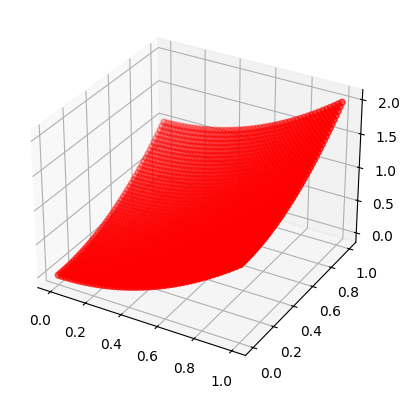

In [8]:
#%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
xs = data_np_1_s[:, 0]
ys = data_np_1_s[:, 1]
zs = data_np_1_s[:, 2]
#ax.scatter(xs, ys, vt, color = 'blue')
ax.scatter(xs, ys, zs, color = 'red')
plt.show()

In [9]:
data_np_2_s = np.concatenate([data_np_2, (np.sin(2.0 * np.pi * data_np_2[:, 0]) + data_np_2[:, 1] * data_np_2[:, 1]).reshape((-1, 1))], axis = 1)

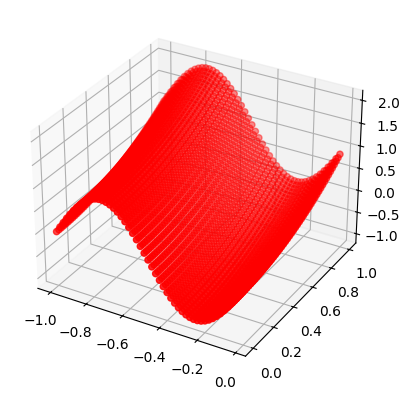

In [10]:
#%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
xs = data_np_2_s[:, 0]
ys = data_np_2_s[:, 1]
zs = data_np_2_s[:, 2]
#ax.scatter(xs, ys, vt, color = 'blue')
ax.scatter(xs, ys, zs, color = 'red')
plt.show()

In [11]:
test_np = np.concatenate([data_np_1_s, data_np_2_s], axis = 0)

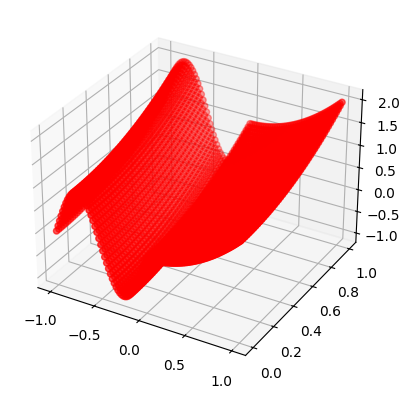

In [12]:
#%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
xs = test_np[:, 0]
ys = test_np[:, 1]
zs = test_np[:, 2]
#ax.scatter(xs, ys, vt, color = 'blue')
ax.scatter(xs, ys, zs, color = 'red')
plt.show()

In [13]:
data_np_4_s = np.concatenate([data_np_4, (np.cos(2.0 * np.pi * data_np_4[:, 1]) - 1.0 + data_np_4[:, 0] * data_np_4[:, 0]).reshape((-1, 1))], axis = 1)

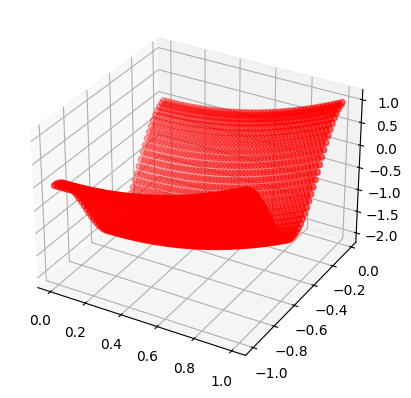

In [14]:
#%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
xs = data_np_4_s[:, 0]
ys = data_np_4_s[:, 1]
zs = data_np_4_s[:, 2]
#ax.scatter(xs, ys, vt, color = 'blue')
ax.scatter(xs, ys, zs, color = 'red')
plt.show()

In [15]:
test_np = np.concatenate([data_np_1_s, data_np_2_s, data_np_4_s], axis = 0)

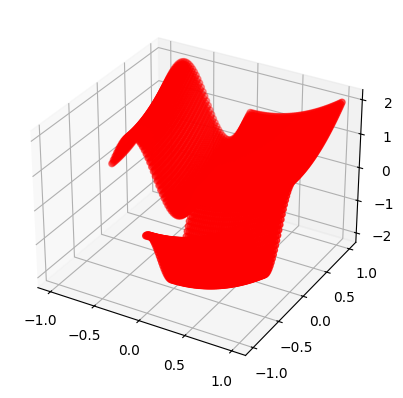

In [16]:
#%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
xs = test_np[:, 0]
ys = test_np[:, 1]
zs = test_np[:, 2]
#ax.scatter(xs, ys, vt, color = 'blue')
ax.scatter(xs, ys, zs, color = 'red')
plt.show()

In [17]:
data_np_3_s = np.concatenate([data_np_3, (np.sin(2.0 * np.pi * data_np_3[:, 0]) - 1.0 + np.cos(2.0 * np.pi * data_np_3[:, 1])).reshape((-1, 1))], axis = 1)

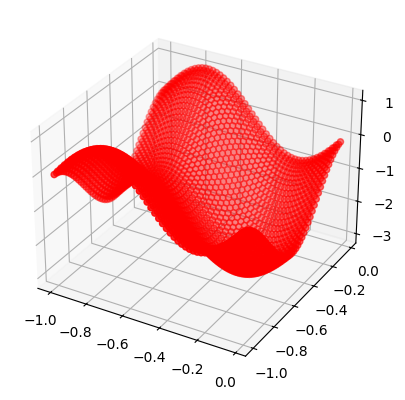

In [18]:
#%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
xs = data_np_3_s[:, 0]
ys = data_np_3_s[:, 1]
zs = data_np_3_s[:, 2]
#ax.scatter(xs, ys, vt, color = 'blue')
ax.scatter(xs, ys, zs, color = 'red')
plt.show()

In [19]:
test_np = np.concatenate([data_np_1_s, data_np_2_s, data_np_3_s, data_np_4_s], axis = 0)

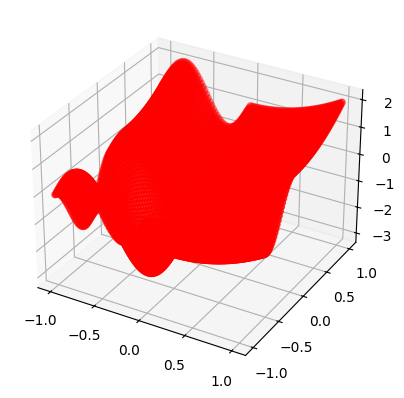

In [20]:
#%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
xs = test_np[:, 0]
ys = test_np[:, 1]
zs = test_np[:, 2]
#ax.scatter(xs, ys, vt, color = 'blue')
ax.scatter(xs, ys, zs, color = 'red')
plt.show()

In [21]:
plt.close()

In [22]:
data_np = copy.deepcopy(test_np)

In [23]:
data_np[:, 2] = data_np[:, 2] + np.random.normal(0, 0.1, data_np.shape[0])

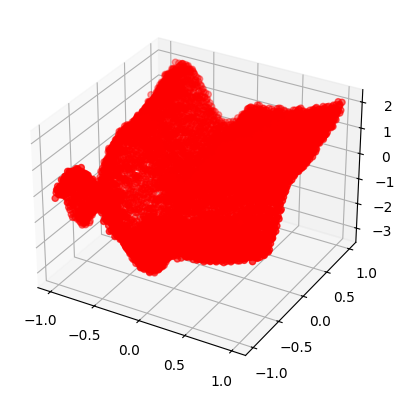

In [24]:
#%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
xs = data_np[:, 0]
ys = data_np[:, 1]
zs = data_np[:, 2]
#ax.scatter(xs, ys, vt, color = 'blue')
ax.scatter(xs, ys, zs, color = 'red')
plt.show()

In [25]:
class Config(object):
    Ntime=4 ## There are four snn parts 
    
    #dim=64
    dim = 16
    
    x_dim=2; 
    y_dim=1; 
    
    logging_frequency = 100
    verbose = True
    y_init_range = [0, 1]
    
    #num_hiddens = [dim,256, dim] ## this is for each sub module
    num_hiddens = [dim, 32, dim]
    
def get_config(name):
    try:
        return globals()[name]
    except KeyError:
        raise KeyError("config not defined.")

cfg=get_config("Config")

In [26]:
class Dense(nn.Module):
    def __init__(self, cin, cout, batch_norm = False, activate = True):
        super(Dense, self).__init__()
        self.cin = cin
        self.cout = cout
        self.activate = activate
        self.linear = nn.Linear(self.cin, self.cout)

        if batch_norm: 
            self.bn = nn.BatchNorm1d(cout, eps = EPSILON, momentum = MOMENTUM)
        else:
            self.bn = None

    def forward(self, X):
        x = X.to(torch.float64)
        x = self.linear(x)
        if self.bn is not None:
            x = self.bn(x)
        if self.activate:
            x = torch.relu(x)
        return x

class FClayerDrift(nn.Module):
    def __init__(self, config, batch_norm = False):
        super(FClayerDrift, self).__init__()
        self.bn = nn.BatchNorm1d(config.num_hiddens[0], eps = EPSILON, momentum = MOMENTUM)

        self.layers = [Dense(config.num_hiddens[i - 1], config.num_hiddens[i]) for i in range(1, len(config.num_hiddens) - 1)]
        self.layers += [Dense(config.num_hiddens[-2], config.num_hiddens[-1], activate = False)]
        self.layers = nn.Sequential(*self.layers)

    def forwardX(self, X):
        #x = self.bn(X)
        x = self.layers(X)
        return x

In [27]:
class Dense2(nn.Module):
    def __init__(self, cin, cout, batch_norm = False, activate = True):
        super(Dense2, self).__init__()
        self.cin = cin
        self.cout = cout
        self.activate = activate
        self.linear = nn.Linear(self.cin, self.cout)

        if batch_norm:
            self.bn=nn.BatchNorm1d(cout,eps=EPSILON,momentum=MOMENTUM)
        else:
            self.bn=None
        
    def forward(self, x):
        x = x.to(torch.float64)
        x=self.linear(x)
        if self.bn is not None: 
            x=self.bn(x)
        if self.activate:
            x=torch.relu(x)
        return x

class FClayerDiffusion(nn.Module):
    def __init__(self, config, batch_norm = False):
        super(FClayerDiffusion, self).__init__()

        self.bn=nn.BatchNorm1d(config.num_hiddens[0],eps=EPSILON,momentum=MOMENTUM)
        self.layers=[Dense2(config.num_hiddens[i-1],config.num_hiddens[i]) for i in range(1, len(config.num_hiddens)-1)]
        self.layers+=[Dense2(config.num_hiddens[-2], config.num_hiddens[-1],activate=False)]
        self.layers=nn.Sequential(*self.layers)

    def forwardX(self, X):
        x = self.bn(X)
        x = self.layers(X)
        return torch.sigmoid(x)

In [28]:
loss_fn = nn.MSELoss(reduction = 'mean')
class SNN(nn.Module):
    def __init__(self, config, X, y, batch_size):
        super(SNN, self).__init__()
        self.config = config
        self.X = X
        self.driftList = nn.ModuleList([FClayerDrift(self.config) for _ in range(self.config.Ntime)])
        self.diffusionList=nn.ModuleList([FClayerDiffusion(self.config) for _ in range(self.config.Ntime)])
 
        self.project0=Dense(self.config.x_dim,self.config.dim,activate=False)
        self.project_end=Dense(self.config.dim, self.config.y_dim, activate=False)

        self.batch_size = batch_size
        self.h = 1.0 / self.config.Ntime
        self.sqrth = np.sqrt(self.h)
        self.W_p=[torch.tensor(np.random.normal(0,1, (self.X.shape[0],self.config.dim)),dtype=torch.float32, requires_grad=False).to(device) 
                  for i in range(0,self.config.Ntime)]
        self.y = torch.from_numpy(y).unsqueeze(1)

    def forwardX(self, x, idx):
        x = x.to(torch.float64)
        xMat = []
        xMat.append(x)
        x = self.project0(x)
        xMat.append(x)
        for i in range(0, self.config.Ntime):
            x = x + self.driftList[i].forwardX(x) * self.h + self.diffusionList[i].forwardX(x) * self.W_p[i][idx, :] * self.sqrth
            xMat.append(x)

        x = self.project_end(x)
        xMat.append(x)
        return xMat

    def backwardYZ(self, xMat, idx):
        yMat = []
        zMat = []

        x_terminal = xMat[-1]
        loss = loss_fn(x_terminal, self.y[idx, :].to(device))

        y_terminal = torch.autograd.grad(outputs = [loss], inputs = [x_terminal], grad_outputs = torch.ones_like(loss), 
                                         allow_unused = True, retain_graph = True, create_graph = True)[0]
        yMat.append(y_terminal)
        xin = xMat[-2]
        hami = torch.sum(yMat[-1].detach() * self.project_end(xin), dim = 1)
        ytemp = torch.autograd.grad(outputs = [hami], inputs = [xin], grad_outputs = torch.ones_like(hami), 
                                    allow_unused = True, retain_graph = True, create_graph = True)[0]
        yMat.append(ytemp)

        for i in range(self.config.Ntime - 1, -1, -1):
            xin = xMat[i + 1]
            ztemp = yMat[-1] * self.W_p[i][idx, :] / self.sqrth
            zMat.append(ztemp)

            hami = torch.sum(yMat[-1].detach() * self.driftList[i].forwardX(xin) + ztemp.detach() * self.diffusionList[i].forwardX(xin), dim = 1)
            hami_x = torch.autograd.grad(outputs = [hami], inputs = [xin], grad_outputs = torch.ones_like(hami), 
                                         allow_unused = True, retain_graph = True, create_graph = True)[0]
            ytemp = yMat[-1] + hami_x * self.h
            yMat.append(ytemp)

        xin = xMat[0]
        hami = torch.sum(yMat[-1].detach() * self.project0(xin), dim = 1)
        hami_x = torch.autograd.grad(outputs = [hami], inputs = [xin], grad_outputs = torch.ones_like(hami), 
                                     allow_unused = True, retain_graph = True, create_graph = True)[0]
        ytemp = hami_x
        yMat.append(ytemp)
        return yMat, zMat

    def Hamcompute(self, xMat, yMat, zMat):
        total_ham = 0.0
        ham = torch.sum(yMat[-2].detach() * self.project0(xMat[0].detach()))
        total_ham += ham

        for i in range(0, self.config.Ntime):
            ham = torch.sum(yMat[self.config.Ntime - 1].detach() * self.driftList[i].forwardX(xMat[i + 1].detach()) + zMat[i].detach() * self.diffusionList[i].forwardX(xMat[i + 1].detach()))
            total_ham += ham

        ham = torch.sum(yMat[0].detach() * self.project_end(xMat[-2].detach()))
        total_ham += ham
        return total_ham / self.batch_size

    def predict(self, X):
        xx = X.clone()
        x = self.project0(xx)
        for i in range(0, self.config.Ntime):
            x = x + self.driftList[i].forwardX(x) * self.h + self.diffusionList[i].forwardX(x) * torch.FloatTensor(normal.rvs(size = [x.shape[0], self.config.dim])).to(device) * self.sqrth
        x = self.project_end(x)
        return x
        
    def predict_drift(self, X):
        xx = X.clone()
        x = self.project0(xx)
        for i in range(0, self.config.Ntime):
            x = x + self.driftList[i].forwardX(x) * self.h
        x = self.project_end(x)
        return x

In [29]:
def training(model, X):
    optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4, weight_decay = 1e-8)
    #for e in tqdm(range(epoch)):
    for e in range(epoch):
        optimizer.zero_grad()
        indices = np.random.randint(0, X.shape[0], size = batch_size)
        batch_x = X[indices, :].to(device)

        xmat = model.forwardX(batch_x, indices)
        ymat, zmat = model.backwardYZ(xmat, indices)
        loss_temp = model.Hamcompute(xmat, ymat, zmat)
        loss_temp.backward()
        optimizer.step()
    return model

In [30]:
batch_size = 256
setter = 1
#model = SNN(cfg, XX1, output1, batch_size).to(device)
epoch = 5000

In [31]:
input2 = data_np[:, :2].astype(float)
output2 = data_np[:, 2].astype(float)
if type(input2) == np.ndarray:
    XX2 = torch.tensor(input2, requires_grad = True)

In [32]:
batch_size = 256
setter = 1
model2 = SNN(cfg, XX2, output2, batch_size).to(device)
epoch = 2000
local_size = 100
sparse_size = 20

In [33]:
temp = SNN(cfg, XX2, output2, batch_size).to(device)
w_global = temp.state_dict()
w_local = [copy.deepcopy(w_global) for _ in range(40)]

In [34]:
w_count = {}
for i in range(40):
    w_count[str(i)] = 0

In [35]:
local_set = []
for i in range(40):
    if i < 10:
        local_set.append(np.concatenate((np.random.choice(range(int(data_np_1.shape[0])), size = local_size, replace = False), 
                                         np.random.choice(range(int(data_np_1.shape[0]), data_np.shape[0]), size = sparse_size, replace = False)), 
                                        axis = None))
    elif i < 20:
        local_set.append(np.concatenate((np.random.choice(range(int(data_np_1.shape[0]), int(data_np_1.shape[0] + data_np_2.shape[0])), size = local_size, replace = False), 
                                         np.random.choice(list(range(int(data_np_1.shape[0]))) + list(range(int(data_np_1.shape[0] + data_np_2.shape[0]), data_np.shape[0])), size = sparse_size, replace = False)), 
                                        axis = None))
    elif i < 30: 
        local_set.append(np.concatenate((np.random.choice(range(data_np_1.shape[0] + data_np_2.shape[0], data_np.shape[0] - data_np_4.shape[0]), size = local_size, replace = False), 
                                         np.random.choice(list(range(data_np_1.shape[0] + data_np_2.shape[0])) + list(range(data_np.shape[0] - data_np_4.shape[0], data_np.shape[0])), size = sparse_size, replace = False)), 
                                        axis = None))
    else:
        local_set.append(np.concatenate((np.random.choice(range(data_np.shape[0] - data_np_4.shape[0], data_np.shape[0]), size = local_size, replace = False), 
                                         np.random.choice(range(data_np.shape[0] - data_np_4.shape[0]), size = sparse_size, replace = False)), 
                                        axis = None))

In [36]:
def training(model, X):
    optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4, weight_decay = 1e-8)
    #for e in tqdm(range(epoch)):
    for e in range(epoch):
        optimizer.zero_grad()
        indices = np.random.randint(0, X.shape[0], size = batch_size)
        batch_x = X[indices, :].to(device)

        xmat = model.forwardX(batch_x, indices)
        ymat, zmat = model.backwardYZ(xmat, indices)
        loss_temp = model.Hamcompute(xmat, ymat, zmat)
        loss_temp.backward()
        optimizer.step()
    return model

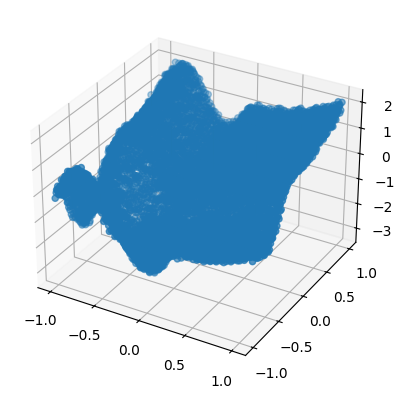

In [37]:
#%matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
xs = data_np[:, 0]
ys = data_np[:, 1]
zs = data_np[:, 2]
ax.scatter(xs, ys, zs)
plt.show()

In [45]:
for i in tqdm(range(25)):
    idxs_users = np.random.choice(range(40), 4, replace = False)
    temp_model = []
    for idx in idxs_users:
        w_count[str(idx)] = w_count[str(idx)] + 1
        XX3 = XX2[local_set[idx], :]
        output3 = output2[local_set[idx]]
        temp = SNN(cfg, XX3, output3, batch_size).to(device)
        temp.load_state_dict(w_local[idx])
        temp = training(temp, XX3)
        temp_model.append(copy.deepcopy(temp.state_dict()))
    w_global = FedAvg(temp_model)
    j = 0
    for j in range(len(w_local)):
        w_local[j] = copy.deepcopy(w_global)

100%|██████████| 25/25 [1:09:18<00:00, 166.32s/it]


In [39]:
model1 = SNN(cfg, XX2, output2, batch_size).to(device)
model1.load_state_dict(w_global)

<All keys matched successfully>

In [56]:
XX4 = XX2.to(device)
vt = model1.predict(XX4).cpu().detach().numpy()

In [57]:
temp_list = np.random.choice(range(vt.shape[0]), 50, replace = False)

In [109]:
torch.save(model1.state_dict(), 'FedSNN_2D_Function.pth')

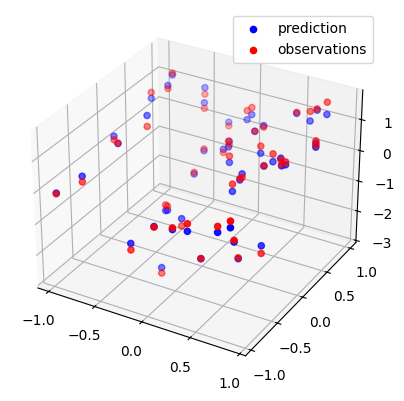

In [58]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
xs = data_np[:, 0][temp_list]
ys = data_np[:, 1][temp_list]
zs = data_np[:, 2][temp_list]
vttt = vt[temp_list]
ax.scatter(xs, ys, vttt.reshape(-1), color = 'blue', label = 'prediction')
ax.scatter(xs, ys, zs, color = 'red', label = 'observations')
plt.legend(loc = 'upper right')
plt.show()

(50,)

In [66]:
print('MSE to data:', (np.square(vttt - zs.reshape(50, 1))).mean())
#print('MSE to function:', (np.square(vt - xs * xs - ys * ys)).mean())

MSE to data: 0.028032118744769782


In [45]:
plt.close()

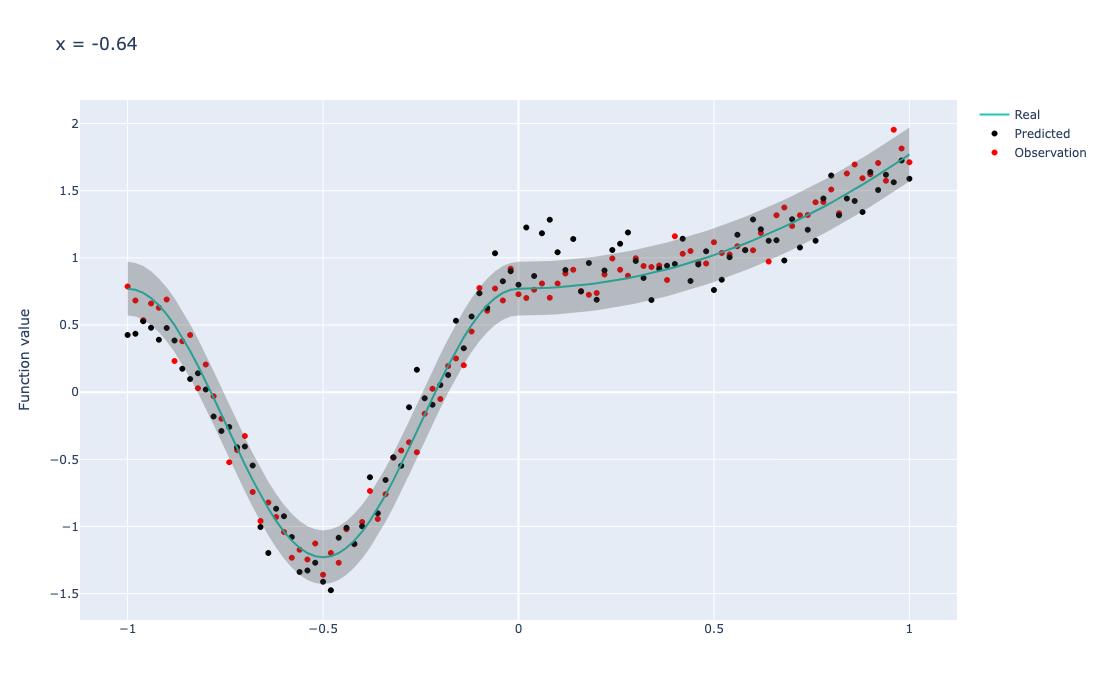

In [163]:
#fixed_x = np.random.randint(2)
#fixed_x = 0
fixed_x = 1
fixed_y = 1 - fixed_x
if fixed_x and not fixed_y:
    fixed_x_value = XX4[np.random.randint(XX4.shape[0]), 0]
    fixed_x_value = fixed_x_value - fixed_x_value - 0.64
    vx = model1.predict(XX4[XX4[:, 0] == fixed_x_value]).cpu().detach().numpy()
    fig = go.Figure([
        go.Scatter(
            name = 'Observation', 
            x = data_np[data_np[:, 0] == fixed_x_value.cpu().detach().numpy()][:, 1], 
            #y = vx.reshape(-1),
            y = data_np[data_np[:, 0] == fixed_x_value.cpu().detach().numpy()][:, 2], 
            mode = 'markers', 
            marker = dict(color = 'red'), 
        ), 
        go.Scatter(
            name = 'Predicted', 
            x = data_np[data_np[:, 0] == fixed_x_value.cpu().detach().numpy()][:, 1], 
            y = vx.reshape(-1),
            #y = data_np[data_np[:, 0] == fixed_x_value.detach().numpy()][:, 2], 
            mode = 'markers', 
            marker = dict(color = 'black'), 
        ), 
        go.Scatter(
            name = 'Real', 
            x = np.concatenate((data_np[data_np[:, 0] == fixed_x_value.cpu().detach().numpy()][:, 1][51: ], 
                                data_np[data_np[:, 0] == fixed_x_value.cpu().detach().numpy()][:, 1][: 51]), axis = 0), 
            y = np.concatenate((test_np[test_np[:, 0] == fixed_x_value.cpu().detach().numpy()][:, 2][51: ], 
                                test_np[test_np[:, 0] == fixed_x_value.cpu().detach().numpy()][:, 2][: 51]), axis = 0), 
            mode = 'lines', 
            line = dict(color = 'rgb(31, 199, 180)'), 
        ), 
        go.Scatter(
            name = 'Upper Bound', 
            x = np.concatenate((data_np[data_np[:, 0] == fixed_x_value.cpu().detach().numpy()][:, 1][51: ], 
                                data_np[data_np[:, 0] == fixed_x_value.cpu().detach().numpy()][:, 1][: 51]), axis = 0), 
            y = np.concatenate((test_np[test_np[:, 0] == fixed_x_value.cpu().detach().numpy()][:, 2][51: ], 
                                test_np[test_np[:, 0] == fixed_x_value.cpu().detach().numpy()][:, 2][: 51]), axis = 0) + 0.2, 
            mode = 'lines', 
            marker = dict(color = '#444'), 
            line = dict(width = 0), 
            showlegend = False
        ), 
        go.Scatter(
            name = 'Lower Bound', 
            x = np.concatenate((data_np[data_np[:, 0] == fixed_x_value.cpu().detach().numpy()][:, 1][51: ], 
                                data_np[data_np[:, 0] == fixed_x_value.cpu().detach().numpy()][:, 1][: 51]), axis = 0), 
            y = np.concatenate((test_np[test_np[:, 0] == fixed_x_value.cpu().detach().numpy()][:, 2][51: ], 
                                test_np[test_np[:, 0] == fixed_x_value.cpu().detach().numpy()][:, 2][: 51]), axis = 0) - 0.2, 
            marker = dict(color = '#444'), 
            line = dict(width = 0), 
            mode = 'lines', 
            fillcolor = 'rgba(68, 68, 68, 0.3)', 
            fill = 'tonexty', 
            showlegend = False
        ), 
    ])
    temp = str(np.round(fixed_x_value.cpu().detach().numpy(), 3))
    fig.update_layout(
        width = 1000,
        height = 700,
        yaxis = dict(title = dict(text = 'Function value')), 
        title = dict(text = 'x = ' + temp), 
        hovermode = 'x'
    )
    fig.write_image("temp_x.png")
    fig.show()
elif fixed_y and not fixed_x:
    fixed_y_value = XX4[np.random.randint(XX4.shape[0]), 1]
    fixed_y_value = fixed_y_value - fixed_y_value + 0.96
    vy = model1.predict(XX4[XX4[:, 1] == fixed_y_value]).cpu().detach().numpy()
    temp = np.concatenate((data_np[data_np[:, 1] == fixed_y_value.cpu().detach().numpy()][:, 0].reshape(-1, 1), 
                           data_np[data_np[:, 1] == fixed_y_value.cpu().detach().numpy()][:, 2].reshape(-1, 1), 
                           test_np[test_np[:, 1] == fixed_y_value.cpu().detach().numpy()][:, 2].reshape(-1, 1), 
                           vy), axis = 1)
    temp[np.argsort(temp[:, 0])]
    if fixed_y_value >= 0: 
        temp = np.concatenate((temp[51: , :], temp[: 51, :]), axis = 0)
    fig = go.Figure([
        go.Scatter(
            name = 'Observation', 
            x = data_np[data_np[:, 1] == fixed_y_value.cpu().detach().numpy()][:, 0], 
            #y = vx.reshape(-1),
            y = data_np[data_np[:, 1] == fixed_y_value.cpu().detach().numpy()][:, 2], 
            mode = 'markers', 
            marker = dict(color = 'red'), 
        ), 
        go.Scatter(
            name = 'Predicted', 
            x = data_np[data_np[:, 1] == fixed_y_value.cpu().detach().numpy()][:, 0], 
            y = vy.reshape(-1),
            #y = data_np[data_np[:, 0] == fixed_x_value.detach().numpy()][:, 2], 
            mode = 'markers', 
            marker = dict(color = 'black'), 
        ), 
        go.Scatter(
            name = 'Real', 
            x = temp[:, 0], 
            y = temp[:, 2], 
            mode = 'lines', 
            line = dict(color = 'rgb(31, 199, 180)'), 
        ), 
        go.Scatter(
            name = 'Upper Bound', 
            x = temp[:, 0], 
            y = temp[:, 2] + 0.2, 
            mode = 'lines', 
            marker = dict(color = '#444'), 
            line = dict(width = 0), 
            showlegend = False
        ), 
        go.Scatter(
            name = 'Lower Bound', 
            x = temp[:, 0], 
            y = temp[:, 2] - 0.2, 
            marker = dict(color = '#444'), 
            line = dict(width = 0), 
            mode = 'lines', 
            fillcolor = 'rgba(68, 68, 68, 0.3)', 
            fill = 'tonexty', 
            showlegend = False
        ), 
    ])
    temptxt = str(np.round(fixed_y_value.cpu().detach().numpy(), 3))
    fig.update_layout(
        width = 1000,
        height = 700,
        yaxis = dict(title = dict(text = 'Function value')), 
        title = dict(text = 'y = ' + temptxt), 
        hovermode = 'x'
    )
    fig.write_image("temp_y.png")
    fig.show()
elif fixed_x and fixed_y:
    print("Fix only one axis.")
else:
    print("Fix one axis.")

In [166]:
loss_fn(torch.from_numpy(vx).to(device), torch.from_numpy(data_np[data_np[:, 0] == fixed_x_value.cpu().detach().numpy()][:, 2]).view(-1, 1).to(device))

        

tensor(0.0401, device='cuda:0')

In [165]:
vx.shape


(101, 1)

In [100]:
data_np[data_np[:, 0] == fixed_x_value.cpu().detach().numpy()][:, 1]

(101,)

In [40]:
model1.load_state_dict(torch.load(os.getcwd()+'/FedSNN_2D_Function.pth'))

<All keys matched successfully>

In [41]:
loss_fn(model1.predict(torch.from_numpy(test_np[:, :2]).to(device)), torch.from_numpy(test_np[:, 2]).to(device).view(-1, 1))

tensor(0.0250, device='cuda:0', grad_fn=<MseLossBackward0>)

In [72]:
loss_fn(torch.from_numpy(data_np[:, 2]).view(-1, 1).to(device), torch.from_numpy(test_np[:, 2]).view(-1, 1).to(device))

tensor(0.0101, device='cuda:0')

In [54]:
m = 0
for i in range(100):
    m += loss_fn(model1.predict(XX2.to(device)), torch.from_numpy(test_np[:, 2]).to(device).view(-1, 1))
print(m.detach().cpu().data / 100)

tensor(0.0253)


In [68]:
data_np[:, 2].shape

(10201,)